In [ ]:
%load_ext autoreload
%autoreload 2

In [229]:
import sys
import os

sys.path.append('..')
sys.path.append(os.path.abspath(os.path.join('..', 'magnet-pinn')))
sys.path.append(os.path.abspath(os.path.join('..', 'neuraloperator')))

In [241]:
from torch.utils.data import DataLoader

from magnet_pinn.data.transforms import Compose, Crop, CoilEnumeratorPhaseShift
from magnet_pinn.data.grid import MagnetGridIterator

TRAIN_DIR = "../data/processed/batch_17/grid_voxel_size_4_data_type_float32"
VAL_DIR = "../data/processed/batch_17/grid_voxel_size_4_data_type_float32"

augmentation = Compose(
    [
        Crop(crop_size=(100, 100, 100)),
        CoilEnumeratorPhaseShift(num_coils=8)
    ]
)

val_set = MagnetGridIterator(VAL_DIR, transforms=augmentation, num_samples=8)
val_loader = iter(DataLoader(val_set, batch_size=1))

In [ ]:
from mrifield.models import UNet3D
from neuralop.models import FNO, UNO
from mrifield.train.lit_mrifield import LitMRIField
from magnet_pinn.utils import StandardNormalizer

CKPT = "fno/s767wz93/fno_16M_16M_42H.ckpt"

#model = UNet3D(in_channels=5, out_channels=12)
model = FNO(n_modes=(16, 16, 16), in_channels=5, out_channels=12, hidden_channels=42, positional_embedding=None)
#model = UNO(in_channels=5, out_channels=12, hidden_channels=16, uno_out_channels=[32,64,64,32], uno_n_modes=[[16,16,16],[16,16,16],[16,16,16],[16,16,16]], uno_scalings=[[1,1,1],[0.5,0.5,0.5],[1,1,1],[2,2,2]], channel_mlp_skip='linear')

train_input_normalizer = StandardNormalizer.load_from_json(f"{TRAIN_DIR}/normalization/input_normalization.json")
train_target_normalizer = StandardNormalizer.load_from_json(f"{TRAIN_DIR}/normalization/target_normalization.json")
val_input_normalizer = StandardNormalizer.load_from_json(f"{VAL_DIR}/normalization/input_normalization.json")
val_target_normalizer = StandardNormalizer.load_from_json(f"{VAL_DIR}/normalization/target_normalization.json")

trained_model = LitMRIField.load_from_checkpoint(
    CKPT,
    model=model,
    train_input_normalizer=train_input_normalizer,
    train_target_normalizer=train_target_normalizer,
    val_input_normalizer=val_input_normalizer,
    val_target_normalizer=val_target_normalizer
)

trained_model.eval()

In [242]:
sample = next(val_loader)
subject = sample['subject']

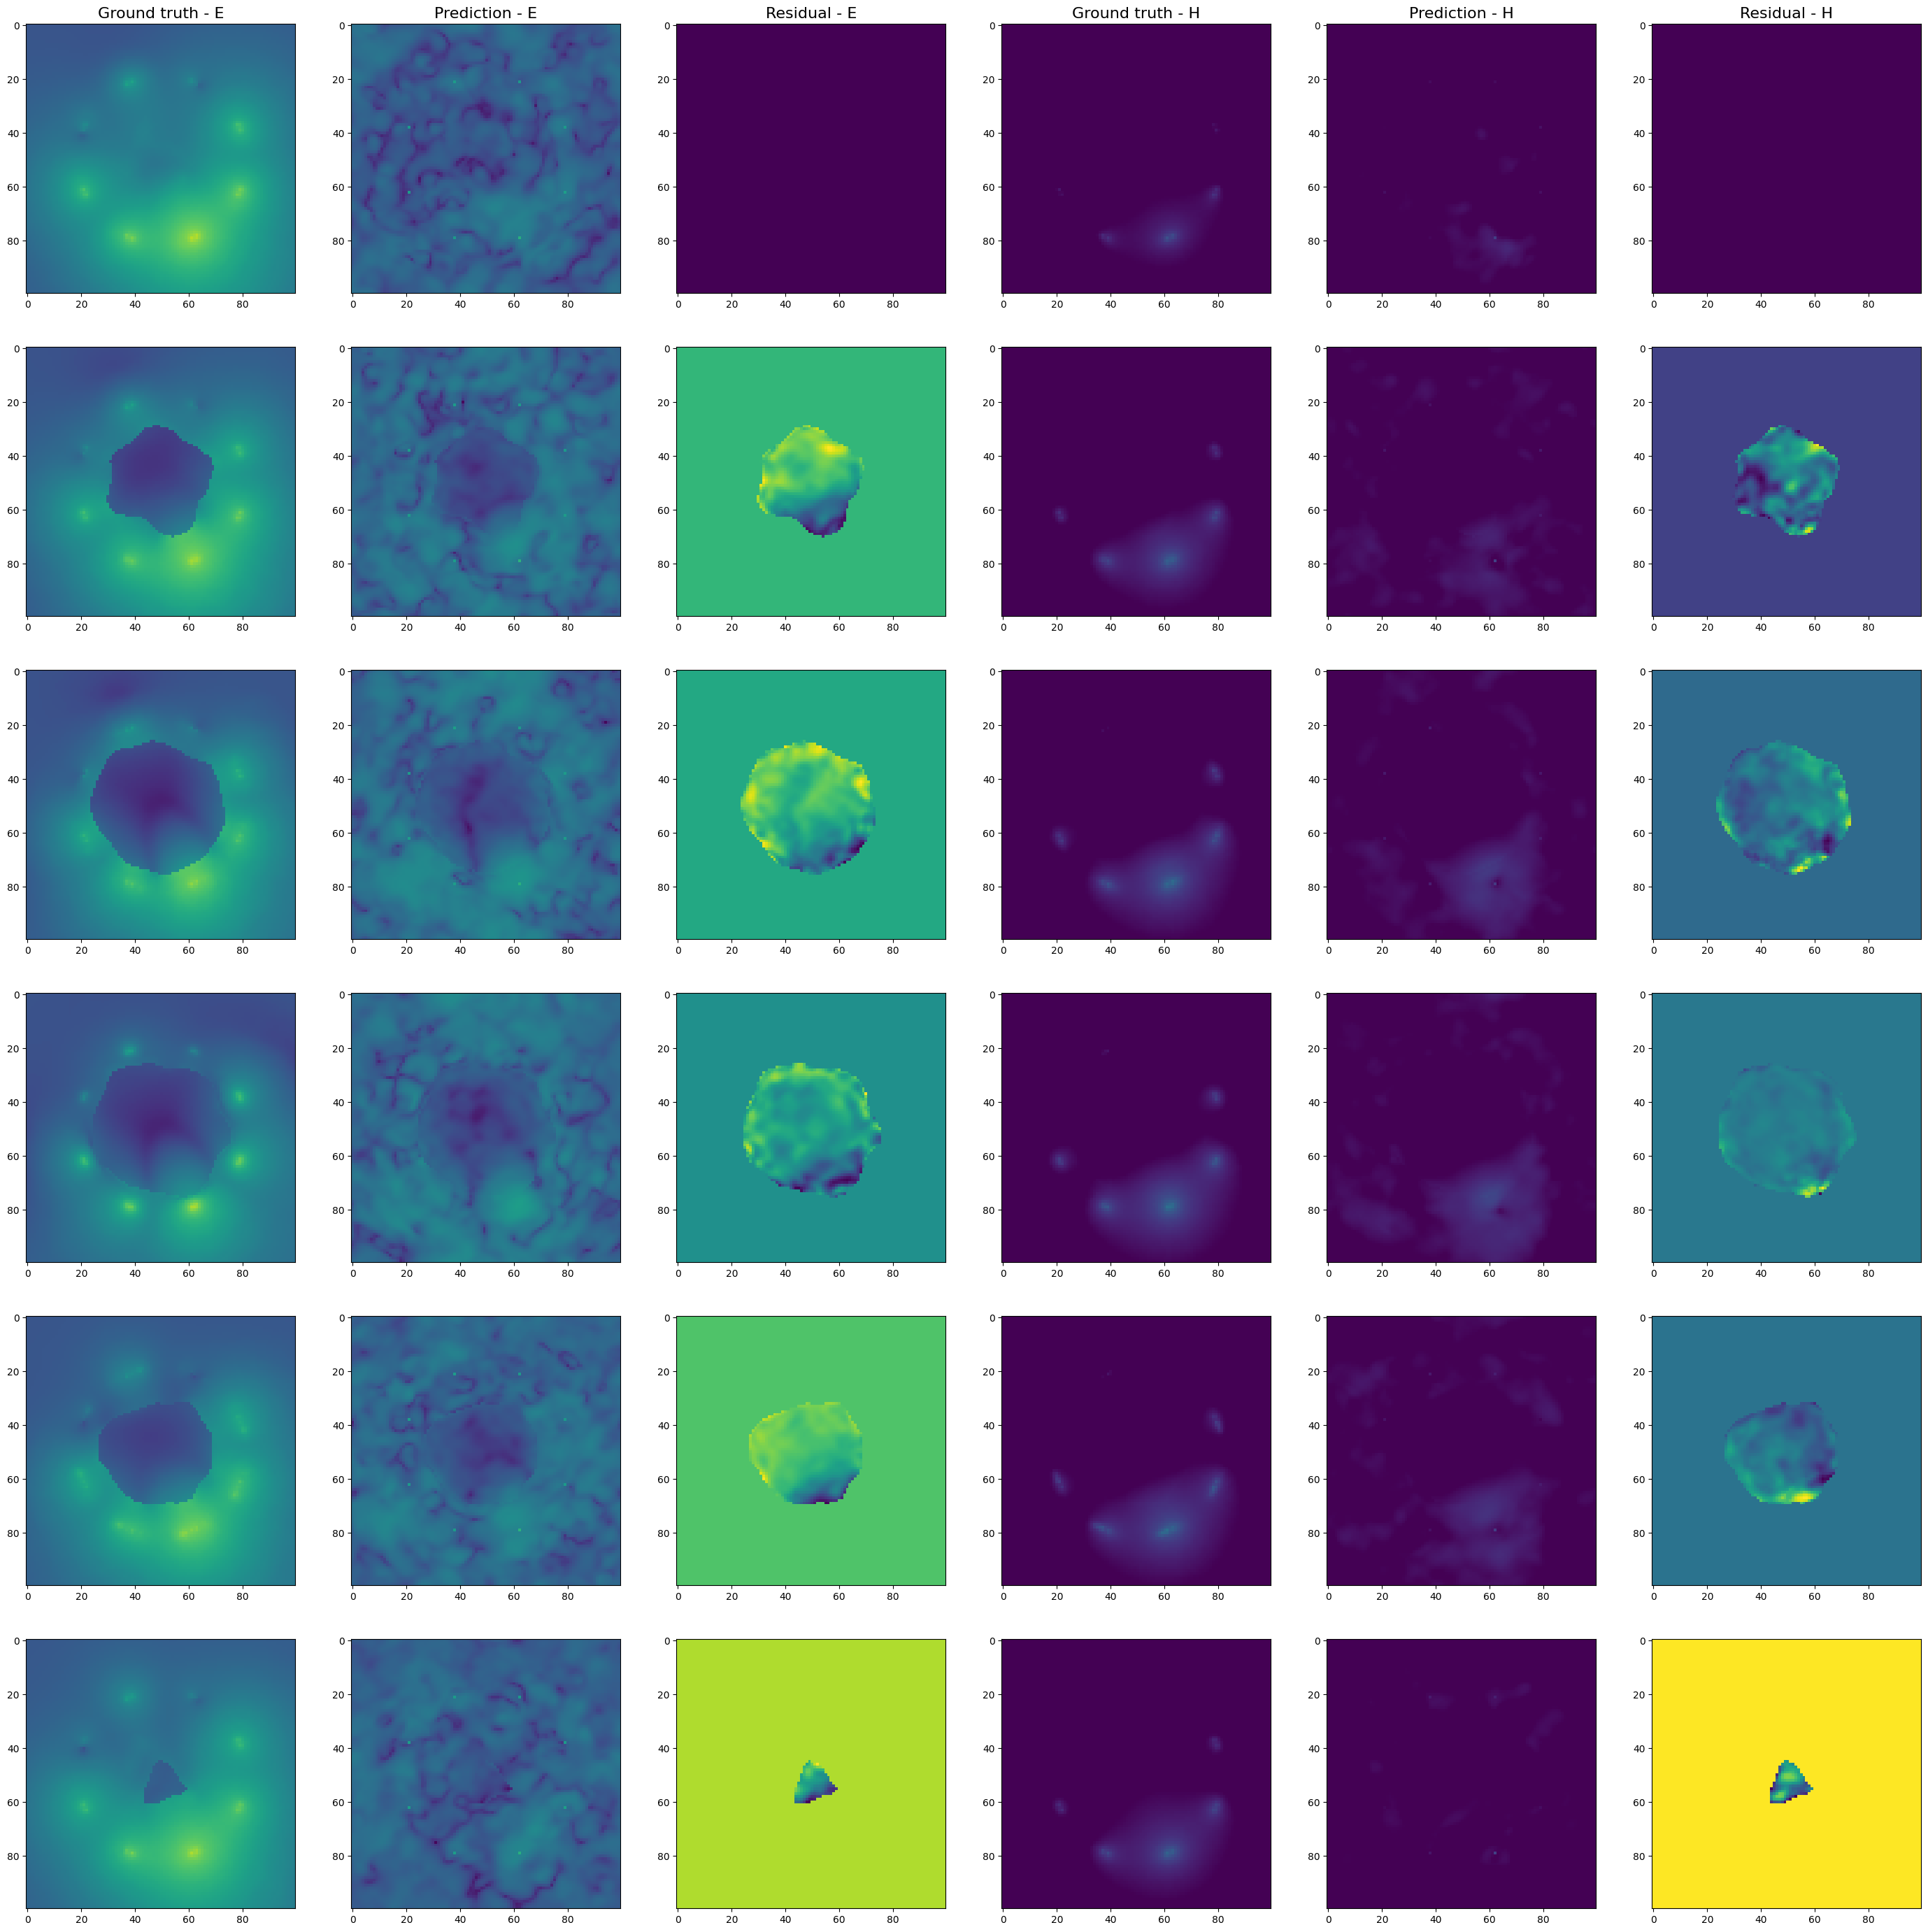

In [243]:
import torch
import einops
import matplotlib.pyplot as plt

sample = next(val_loader)
subject = sample['subject']

# Ground truth
gt_re = sample['field'][0, :, 0, :, :, :, :]
gt_im = sample['field'][0, :, 1, :, :, :, :]

gt = torch.norm(torch.complex(gt_re, gt_im), dim=1)

# Prediction
inputs = sample['input']
coils = sample['coils']

x = val_input_normalizer(torch.cat([inputs, coils], dim=1))
with torch.no_grad():
    pred = val_target_normalizer.inverse(trained_model(x))
    pred = einops.rearrange(pred, 'b (he reim xyz) ... -> b he reim xyz ...', he=2, reim=2, xyz=3)

pr_re = pred[0, :, 0, :, :, :, :]
pr_im = pred[0, :, 1, :, :, :, :]

pr = torch.norm(torch.complex(pr_re, pr_im), dim=1)

# Residuals (Subject)
rs = (pr - gt) * subject

# Plot multiple slices of a single sample
_, axes = plt.subplots(6, 6, figsize=(35, 35))

titles = ['Ground truth - E', 'Prediction - E', 'Residual - E', 'Ground truth - H', 'Prediction - H', 'Residual - H']

e_vmin = min(gt[0, :, :, :].min(), pr[0, :, :, :].min())
e_vmax = max(gt[0, :, :, :].max(), pr[0, :, :, :].max())
h_vmin = min(gt[1, :, :, :].min(), pr[1, :, :, :].min())
h_vmax = max(gt[1, :, :, :].max(), pr[1, :, :, :].max())

rs_e_vmin = rs[0, :, :, :].min()
rs_e_vmax = rs[0, :, :, :].max()
rs_h_vmin = rs[1, :, :, :].min()
rs_h_vmax = rs[1, :, :, :].max()

for column, title in zip(axes[0], titles):
    column.set_title(title, fontsize=16)

for row in range(6):
    slice = 20 + row * 10

    gt_e = axes[row, 0].imshow(gt[0, :, :, slice], cmap='viridis', norm='log', vmin = e_vmin, vmax = e_vmax)
    pr_e = axes[row, 1].imshow(pr[0, :, :, slice], cmap='viridis', norm='log', vmin = e_vmin, vmax = e_vmax)
    rs_e = axes[row, 2].imshow(rs[0, :, :, slice], cmap='viridis')

    gt_h = axes[row, 3].imshow(gt[1, :, :, slice], cmap='viridis', norm='log', vmin = e_vmin, vmax = e_vmax)
    pr_h = axes[row, 4].imshow(pr[1, :, :, slice], cmap='viridis', norm='log', vmin = e_vmin, vmax = e_vmax)
    rs_h = axes[row, 5].imshow(rs[1, :, :, slice], cmap='viridis')

plt.show()

In [ ]:
from tqdm import tqdm
import einops

num_samples = 8
gts = []
prs = []
res = []

for i in tqdm(range(num_samples)):
    sample = next(val_loader)

    # Ground truth
    gt_re = sample['field'][0, :, 0, :, :, :, :]
    gt_im = sample['field'][0, :, 1, :, :, :, :]

    gt = torch.norm(torch.complex(gt_re, gt_im), dim=1)
    gts.append(gt)

    # Prediction
    inputs = sample['input']
    coils = sample['coils']

    x = val_input_normalizer(torch.cat([inputs, coils], dim=1))
    with torch.no_grad():
        pred = val_target_normalizer.inverse(trained_model(x))
        pred = einops.rearrange(pred, 'b (he reim xyz) ... -> b he reim xyz ...', he=2, reim=2, xyz=3)

    pr_re = pred[0, :, 0, :, :, :, :]
    pr_im = pred[0, :, 1, :, :, :, :]
    
    pr = torch.norm(torch.complex(pr_re, pr_im), dim=1)
    prs.append(pr)

    # Residuals (Subject)
    subject =  sample['subject']

    res.append(torch.abs(pr - gt) * subject)

gts = torch.stack(gts)
prs = torch.stack(prs)
res = torch.stack(res)

100%|██████████| 8/8 [00:26<00:00,  3.31s/it]


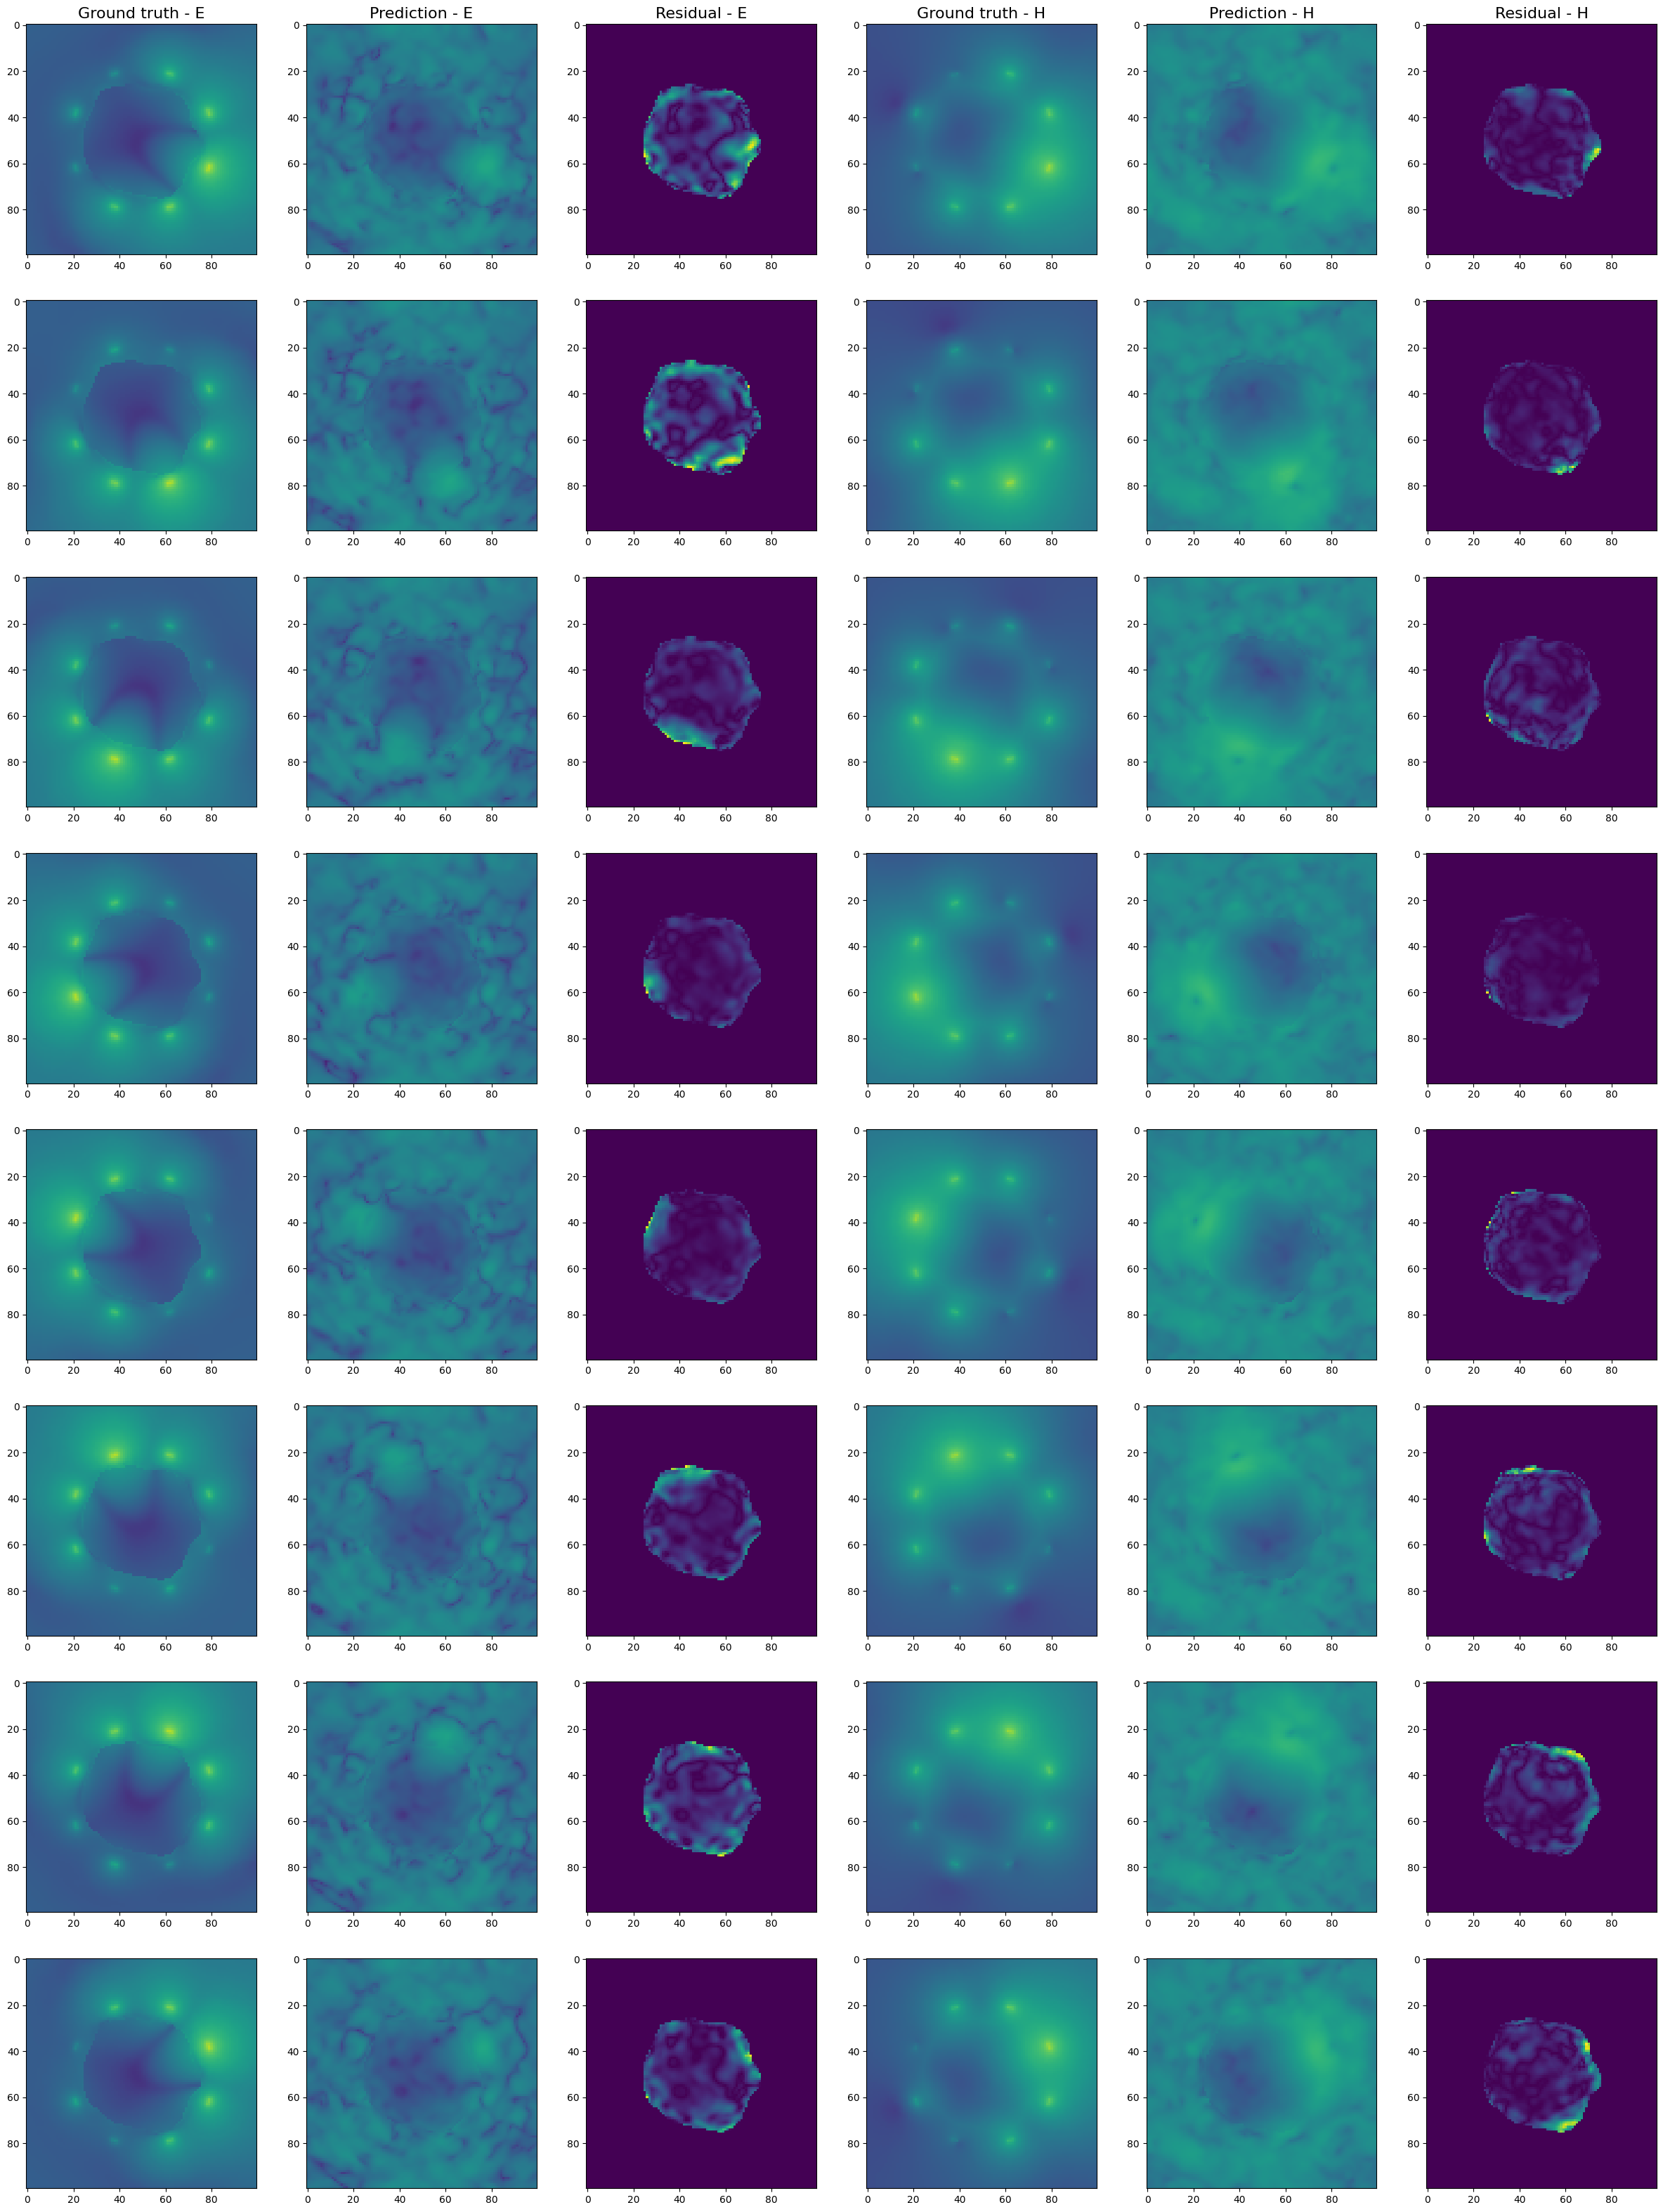

In [239]:
import matplotlib.pyplot as plt

# Plot eight samples, each with only a single coil activated
_, axes = plt.subplots(num_samples, 6, figsize=(30, 40))

titles = ['Ground truth - E', 'Prediction - E', 'Residual - E', 'Ground truth - H', 'Prediction - H', 'Residual - H']

e_vmin = min(gts[:, 0, :, :, :].min(), prs[:, 0, :, :, :].min())
e_vmax = max(gts[:, 0, :, :, :].max(), prs[:, 0, :, :, :].max())
h_vmin = min(gts[:, 1, :, :, :].min(), prs[:, 1, :, :, :].min())
h_vmax = max(gts[:, 1, :, :, :].max(), prs[:, 1, :, :, :].max())

rs_e_vmax = res[0, :, :, :].max()
rs_h_vmax = res[1, :, :, :].max()

for column, title in zip(axes[0], titles):
    column.set_title(title, fontsize=16)

for row in range(num_samples):
    gt_e = axes[row, 0].imshow(gts[row][0, :, :, 50], cmap='viridis', norm='log', vmin = e_vmin, vmax = e_vmax)
    pr_e = axes[row, 1].imshow(prs[row][0, :, :, 50], cmap='viridis', norm='log', vmin = e_vmin, vmax = e_vmax)
    rs_e = axes[row, 2].imshow(res[row][0, :, :, 50], cmap='viridis')

    gt_h = axes[row, 3].imshow(gts[row][1, :, :, 50], cmap='viridis', norm='log', vmin = h_vmin, vmax = h_vmax)
    pr_h = axes[row, 4].imshow(prs[row][1, :, :, 50], cmap='viridis', norm='log', vmin = h_vmin, vmax = h_vmax)
    rs_h = axes[row, 5].imshow(res[row][1, :, :, 50], cmap='viridis')

plt.show()